In [2]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.special import jv, kv
from scipy.special import j1 # Bessel function of the first kind of order 1, for the diffraction pattern calculation
from scipy.optimize import root_scalar
from scipy.constants import c, epsilon_0, mu_0, pi
import scipy.integrate as integrate

In [3]:
# jn_zeros is a function that returns the zeros of the Bessel function of the first kind, 
# which are needed to find the roots for the LP01 mode in a step-index fibre
from scipy.special import jn_zeros  # NEW: needed to get the first zero of J0

In [4]:
from scipy.optimize import brentq
from scipy.optimize import fminbound
# The Brent's method is a root-finding algorithm that combines the bisection method, the secant method, and 
# inverse quadratic interpolation. 
# https://en.wikipedia.org/wiki/Brent%27s_method
# It is designed to find roots of a continuous function within a specified interval where the function changes
#  sign. The method is efficient and robust, making it suitable for finding roots of nonlinear equations.

In [5]:
from dataclasses import dataclass

In [6]:
from joblib import Parallel, delayed
import os

In [ ]:
def cutoff(l,m):
    """
    Utility  function which calculates the cutoff frequency Vc, and returns the normalised frequency (V) at cutoff V for
    a given mode l,m. 
    
    Arguments: 
    l: Azimuthal order of the LP mode, integer >= 0
    m: Radial order of the LP mode, integer >= 1
    
    Return value: 

    Vc: Normalised frequency at cutoff for the given mode, equals to the last zero of J_{l-1} for l>=1, 
    and Vc=0 for J_{m-1} for l=0.
    
    """

    if l >= 1: 
        Vc = jn_zeros(l - 1, m)[-1] # jn_zeros computes zeros of integer-order Bessel functions Jn. 
        return Vc # returns cutoff frequency of the mode (LP_lm with l>=1)
    elif l == 0: 
        if m == 1: 
            Vc = 0
            return Vc # returns cutoff frequency of the fundamental mode (LP01)
        else:
            Vc = jn_zeros(1, m - 1)[-1]
            return Vc # returns cutoff frequency of higher order modes (LP0m with m>1)
    else:
        raise ValueError("l must be >= 0")
    

In [ ]:
def modes(V, l_max=5, m_max=5, v_margin=2e-3, az_sym_only=True): 
    """
    For each value of l, calculate the allowed values of m (if any). 
    Returns a list of modes that are supported by the fibre, sorted by their cutoff V-number.

    Arguments: 
    V: Normalised frequency of the fiber, float > 0
    l_max: Maximum azimuthal order to consider, integer >= 0
    m_max: Maximum radial order to consider, integer >= 1
    v_margin: Margin for checking mode existence at cutoff, to account for numerical precision issues. 
    az_sym_only: If True, only include modes with l=0 (azimuthally symmetric modes). If False, include all modes up to l_max. 
    
    Return value: 
    mode_list: A list of [l, m, Vc] for each mode that is supported by the fibre, where Vc is the cutoff V-number for that mode. 
    """ 
    if V <= 0: 
        raise ValueError("V must be >= 0")

    mode_list = []

    # loop over a range from l=0 to l_max, and for each l, loop over m=1 to m_max.
    for l in range(l_max + 1): 
        # if both conditions are met, we only consider modes with l=0, which are azimuthally symmetric.
        if az_sym_only and l != 0: 
            continue # skip modes with l != 0 if az_sym_only is True
        # no else needed, we just continue to the next l if the condition is met. if az_sym_only is False, we will consider all l values up to l_max, 
        # including those with l != 0.
        for m in range(1, m_max + 1): 
            V_c = cutoff(l, m) # calculate cutoff V-number for the mode (l,m)

            if V > V_c + v_margin: 
                mode_list.append([l, m, V_c])

            else: 
                break
    
    # A lambda function is an anonymous function in Python, which can take any number of arguments but can only have one expression. 
    # In this case, the lambda function is used as the key for sorting the mode_list. 
    mode_list.sort(key=lambda mode: mode[2])  # Sort by cutoff V-number

    return mode_list

In [9]:
def function_characteristic_eq(X, V, l): 
    """
    Function that equates to zero at the roots of the characteristic equation. 

    Arguments: 
    X: Normalised transverse propagation constant in the core, float > 0
    V: Normalised frequency of the fibre, float > 0
    Return value: 
    lhs - rhs: The difference between the left-hand side and right-hand side of the characteristic equation, which should be zero at the roots. 
    """
    # Calculate Y based on the relationship Y^2 = V^2 - X^2
    Y = np.sqrt(V**2 - X**2) # Y is the normalised transverse propagation constant in the cladding, and must be real for guided modes (X < V)

    if l > 0: 
        lhs = X * jv(l + 1, X) / jv(l, X)
        rhs = Y * kv(l + 1, Y) / kv(l, Y)
        return lhs - rhs 
    
    elif l == 0:
        lhs = X * jv(1, X) / jv(0, X)
        rhs = Y * kv(1, Y) / kv(0, Y)
        return lhs - rhs
    
    else:
        raise ValueError("l must be >= 0")

In [10]:
from scipy.optimize import brentq
import numpy as np

def find_root_XY(l, m, V, eps=np.finfo(float).eps):
    """
    Calculates the two transverse propagation constants X & Y for a given
    normalised frequency and LP mode (l,m).

    Arguments:
    V: Normalised frequency, float >= cutoff(l,m)
    l: Azimuthal order of the LP mode, integer >= 0
    m: Radial order of the LP mode, integer >= 1
    eps: Margin to avoid numerical issues near cutoff

    Returned values: 
    X_root: Normalised transverse propagation constant in the core, float > 0
    Y_root: Normalised transverse propagation constant in the cladding, float > 0
    """

    # This creates a one-variable function of X only.
    # V and l are "remembered" from the surrounding function.
    f = lambda X: function_characteristic_eq(X, V, l)

    # For all except LP01, Vc is positive. LP01 has cutoff Vc = 0.
    Vc_low = cutoff(l, m)

    if V <= Vc_low: 
        raise ValueError(f"V={V:.6f} is below cutoff for mode ({l},{m})")
    
    Vc_high = cutoff(l + 1, m) # cutoff frequency of the next azimuthal mode with the same radial order
    # We set the lower bound to be slightly above Vc_low to avoid numerical issues
    lower = Vc_low * (1 + eps)
    # Set the upper bound to be slightly below allowed upper limits to avoid numerical issues
    upper = min(Vc_high * (1 - eps), V * (1 - eps)) # between the Vc of the next mode and the maximum allowed by the fibre V
    X_root = brentq(f, lower, upper) # uses lambda function f to find the root in the specified interval
    Y_root = np.sqrt(V**2 - X_root**2)

    return X_root, Y_root

In [11]:
def lp_mode_field_2d(x, y, a, l, X_root, Y_root, angular="cos"): 
    """
    Calculate the 2D electric field distribution of an LP mode in a step-index fibre. 

    Arguments: 
    x: 2D array of x coordinates in physical units (e.g., microns)
    y: 2D array of y coordinates in physical units (e.g., microns)
    a: Core radius of the fibre, in the same units as x and y
    l: Azimuthal order of the LP mode, integer >= 0
    X_root: Normalised transverse propagation constant in the core, float > 0
    Y_root: Normalised transverse propagation constant in the cladding, float > 0

    Return value: 
    E_2d: 2D array of the electric field distribution of the specified LP mode at the given coordinates. 
    I_2d: 2D array of the intensity distribution (|E|^2) of the specified LP mode at the given coordinates.
    """

    r = np.sqrt(x**2 + y**2) # Calculate the radial distance from the center of the fibre
    phi = np.arctan2(y, x) # Calculate the angular coordinate in the 2D grid, arctan2 is tan^-1(y/x) 
    # but takes into account the signs of x and y to determine the correct quadrant 
    rho = r / a # Normalised radial coordinate

    E_mode = np.zeros_like(r, dtype=float)

    # Calculate the field distribution based on the LP mode
    # Angular part: 
    if l ==0:
        fphi = np.ones_like(phi) # For l=0, the angular part is constant so phi=0 for cos(l*phi) 
    else:
        if angular == "cos":
            fphi = np.cos(l * phi)
        elif angular == "sin": 
            fphi = np.sin(l * phi)
        else:
            raise ValueError("angular must be 'cos' or 'sin'")
        
        # At exactly r=0, the asymmetric modes should be zero
        fphi = np.where(r > 0, fphi, 0) # np.where chooses fphi where r>0, else if r!>0 it sets fphi to 0

    # Radial masks: 
    core = r <= a # Boolean mask for core region 
    cladding = r > a # Boolean mask for cladding region

    # 
    # Author's normalization convention:
    # core: J_l(u r/a) / J_l(u)
    # cladding: K_l(w r/a) / K_l(w)
    E_mode[core] = fphi[core] * jv(l, X_root * rho[core])
    
    Constant_C = jv(l, X_root) / kv(l, Y_root) # This constant ensures the field is continuous at r=a
    E_mode[cladding] = fphi[cladding] * Constant_C * kv(l, Y_root * rho[cladding]) 

    I_mode = np.abs(E_mode)**2

    return E_mode, I_mode
    


    

In [ ]:
def diffraction_limited_E_field_at_fibre_2d(x, y, lam0, F_eff, alpha=0.0, E_S=1.0, decentre=None):
    """
    Diffraction-limited telescope image electric field evaluated
    on a 2D grid at the fibre input plane.

    Parameters
    ----------
    x, y : 2D arrays
        Cartesian coordinates at the fibre input plane [m].
        The fibre centre is assumed to be at x=0, y=0.
    lam0 : float
        Wavelength [m].
    F_eff : float
        Effective focal ratio at the fibre input plane.
    alpha : float
        Central obstruction ratio.
    E_S : float
        Overall field amplitude.
    decentre : None or tuple
        If None, the image is centred on the fibre.
        If (dx, dy), the image centre is shifted by dx, dy [m]
        relative to the fibre centre.

    Returns
    -------
    E_image : 2D array
        Electric field at the fibre input plane.
    I_image : 2D array
        Intensity at the fibre input plane.
    """

    if decentre is None:
        dx, dy = 0.0, 0.0
        r_image = np.sqrt(x**2 + y**2)

    else:
        dx, dy = decentre
        # Coordinates relative to the centre of the image/PSF
        x_shifted = x - dx
        y_shifted = y - dy # if we set phi=0, the vertical shift would become zero as we 
        # later set dy=rsin(phi)=r, assuming the shift is purely radial

        # The radial distance from the centre of the PSF is calculated using the coordinates
        r_image = np.sqrt(x_shifted**2 + y_shifted**2)

    # Compute s, the normalized radial coordinate in the image plane, which is used to calculate the Airy pattern.
    s = np.pi * r_image / (lam0 * F_eff)

    airy_term = np.divide(2 * j1(s), s, # Airy pattern term 2*J1(s)/s, which describes the diffraction pattern of a circular aperture.
        out=np.ones_like(s),
        where=s != 0   # to avoid division by zero at the centre of the PSF, where s=0. The limit of 2*j1(s)/s as s->0 is 1, which is consistent with the Airy pattern having a maximum value of 1 at the centre.
    )

    if alpha > 0:
        obstruction_term = np.divide(2 * j1(alpha * s), alpha * s,
            out=np.ones_like(s),
            where=(alpha * s) != 0   # to avoid division by zero at the centre of the PSF, where alpha * s = 0
        )
        E_image = E_S * (airy_term - alpha**2 * obstruction_term)
    else:
        E_image = E_S * airy_term

    I_image = np.abs(E_image)**2

    return E_image, I_image

In [13]:
def coupling_efficiency_2d(E_image, E_mode, x_1d, y_1d): 
    """
    Calculate the 2D coupling efficiency between an image-plane electric field
    and a fibre mode electric field.

    Input:
    E_image: 2D electric field of the image at the fibre input plane
    E_mode: 2D electric field of the fibre LP mode
    x_1d: 1D x-coordinate array used to make the 2D grid [m]
    y_1d: 1D y-coordinate array used to make the 2D grid [m]

    Output:
    eta: coupling efficiency
    numerator = |∫∫ E_image * conj(E_mode) dx dy|^2
    denominator = ∫∫ |E_image|^2 dx dy * ∫∫ |E_mode|^2 dx dy
    """

    # The integrand inside the integral
    overlap_integrand = E_image * np.conjugate(E_mode)

    # First integrate along the direction of x: 
    overlap_x = integrate.simpson(overlap_integrand, x=x_1d, axis=1)
    overlap = integrate.simpson(overlap_x, x=y_1d) 

    # Power is the integral of the electric field amplitude intensity. 
    # The power in each electric field are normalisation factors when we take the product of 
    # power in image field and power in mode field
    P_image_x = integrate.simpson(np.abs(E_image)**2, x=x_1d, axis=1)
    P_image = integrate.simpson(P_image_x, x=y_1d)
    P_mode_x = integrate.simpson(np.abs(E_mode)**2, x=x_1d, axis=1)
    P_mode = integrate.simpson(P_mode_x, x=y_1d)

    # Calculate the coupling efficiency
    numerator = np.abs(overlap)**2
    denominator = P_image * P_mode

    eta = numerator / denominator

    return eta, numerator, denominator

In [14]:
def prepare_modes_2d(
    x, y,
    a, NA, lam0,
    az_sym=True,
    mode_case="few_mode"
):
    """
    Prepare fibre mode fields for a fixed core radius.

    Parameters:
    x, y: 2D coordinate arrays at the fibre input plane [m]
    a: Core radius of the fibre [m]
    NA: Numerical aperture of the fibre
    lam0: Wavelength [m]
    az_sym: If True, only include azimuthally symmetric modes (l=0). If False, 
    include all modes up to l_max.
    mode_case:
        "smf"      -> only LP01
        "few_mode" -> all supported modes, optionally restricted by az_sym
    
    Returns value: 
    prepared_modes: A list of dictionaries containing precomputed fibre mode fields and their properties.
    Includes l, m, cutoff_V, X_root, Y_root, angular, E_mode, I_mode for each mode.
    """

    V = 2 * np.pi * a * NA / lam0

    if mode_case == "smf": # note if the maximum radius leads to V > 2.405, the fibre would support more modes, the case would be impractical
        allmodes = [[0, 1, 0.0]]
        if V > 2.405:
            print(f"Warning: V={V:.3f} > 2.405, the fibre would support more modes than just LP01, the 'smf' case may be impractical.")

    elif mode_case == "few_mode":
        allmodes = modes(V, az_sym_only=az_sym) # compute all modes supported by the fibre based on the V number

        if az_sym:
            allmodes = [mode for mode in allmodes if mode[0] == 0] # only keep azimuthally symmetric modes if az_sym is True

    else:
        raise ValueError("mode_case must be 'smf' or 'few_mode'")

    # Create a list to store the prepared modes
    prepared_modes = []
    # Loop through each mode created from modes() and compute the corresponding electric field distribution
    for mode in allmodes:
        l, m, cutoff_V = mode

        try:
            X_root, Y_root = find_root_XY(l, m, V) # find X_root and Y_root for the mode with l,m, at the given V estimated from a (not Vc)
        except ValueError:
            continue

        if l == 0:
            angular_list = ["cos"] # only one polarisaton for azimuthally symmetric modes, technically for l=0 the angular part is just a constant (cos(0)=1)
        else:
            angular_list = ["cos", "sin"] # both cos and sin polarisations for asymmetric modes

        for angular in angular_list:
            E_mode, I_mode = lp_mode_field_2d(
                x, y,
                a=a,
                l=l,
                X_root=X_root,
                Y_root=Y_root,
                angular=angular
            )

            prepared_modes.append({
                "l": l,
                "m": m,
                "cutoff_V": cutoff_V,
                "X_root": X_root,
                "Y_root": Y_root,
                "angular": angular,
                "E_mode": E_mode,
                "I_mode": I_mode
            })

    return prepared_modes

In [ ]:
def total_eff_2d(
    prepared_modes,
    x, y, x_1d, y_1d,
    lam0, F_eff, alpha,
    decentre=None,
    E_S=1.0
):
    """
    Calculates the total 2D coupling efficiency using precomputed fibre modes.
    Only E_image changes with focal ratio F.

    Parameters:
    prepared_modes: A list of dictionaries containing precomputed fibre mode fields and their properties.
    x, y: 2D coordinate arrays at the fibre input plane [m]
    x_1d, y_1d: 1D coordinate arrays used to make the 2D grid [m]
    lam0: Wavelength [m]
    F_eff: Effective focal ratio to be optimised
    alpha: Divergence angle [rad]
    decentre: Decentre of the image field [m]
    E_S: Source electric field amplitude [V/m]
    """

    E_image, I_image = diffraction_limited_E_field_at_fibre_2d(
        x, y,
        lam0=lam0,
        F_eff=F_eff,
        alpha=alpha,
        E_S=E_S,
        decentre=decentre
    )

    # begin with zero efficiency when we haven't started accumulating eta for any modes
    total = 0.0
    mode_results = [] # array of dictionaries containing mode results

    # for each existing modes in the prepared_modes list, calculate eta at that mode
    for mode in prepared_modes:
        eta, num, den = coupling_efficiency_2d(
            E_image,
            mode["E_mode"],
            x_1d,
            y_1d
        )

        total += eta # accumulate coupling efficiency at each mode to the total coupling efficiency

        mode_results.append({
            "l": mode["l"],
            "m": mode["m"],
            "cutoff_V": mode["cutoff_V"],
            "X_root": mode["X_root"],
            "Y_root": mode["Y_root"],
            "angular": mode["angular"],
            "eta": eta
        })

    return total, mode_results

In [16]:
# def maximize_coupling_fix_a_prepared(
#     prepared_modes,
#     x, y, x_1d, y_1d,
#     lam0, NA,
#     alpha=0.0,
#     decentre=None,
#     E_S=1.0, n_F_grid=60
# ):
#     """
#     Maximise 2D coupling efficiency for a fixed core radius using
#     precomputed fibre modes.

#     This works for:
#     - single-mode case: prepared_modes contains only LP01
#     - few-mode case: prepared_modes contains multiple LP modes
#     Robust optimisation of F_eff.

#     First checks eta(F) on a coarse grid to avoid local maxima,
#     then refines near the best grid value using fminbound. 

#     Returns: 
#     F_opt: Optimal effective focal ratio that maximises coupling efficiency, for the given core radius and precomputed modes. 
#     eta_tot_opt: Total coupling efficiency at the optimal F_eff.
#     mode_results: List of dictionaries containing the specific coupling efficiency of each mode 
#     at the optimal F_eff, with keys "l", "m", "cutoff_V", "X_root", "Y_root", "angular", "eta". 
#     E_image_opt: 2D array of the electric field distribution of the image at the optimal F_eff.
#     I_image_opt: 2D array of the intensity distribution of the image at the optimal F_eff.
#     """

#     def objective(F_eff):
#         total, _ = total_eff_2d(
#             prepared_modes,
#             x, y, x_1d, y_1d,
#             lam0=lam0,
#             F_eff=F_eff,
#             alpha=alpha,
#             decentre=decentre,
#             E_S=E_S
#         )
#         return 1 - total
    
#     F_guess = 1 / (2 * np.tan(np.arcsin(NA)))
#     F_min = F_guess * 0.2
#     F_max = F_guess * 5.0

#     # Coarse global search
#     F_grid = np.linspace(F_min, F_max, n_F_grid)
#     eta_grid = np.array([1 - objective(F) for F in F_grid])

#     idx_best = np.argmax(eta_grid)

#     # Local bracket around the best grid point
#     if idx_best == 0:
#         lower = F_grid[0]
#         upper = F_grid[1]
#     elif idx_best == len(F_grid) - 1:
#         lower = F_grid[-2]
#         upper = F_grid[-1]
#     else:
#         lower = F_grid[idx_best - 1]
#         upper = F_grid[idx_best + 1]

#     # Refine locally
#     F_opt = fminbound(objective, lower, upper)

#     eta_total_opt, mode_results = total_eff_2d(
#         prepared_modes,
#         x, y, x_1d, y_1d,
#         lam0=lam0,
#         F_eff=F_opt,
#         alpha=alpha,
#         decentre=decentre,
#         E_S=E_S
#     )

#     E_image_opt, I_image_opt = diffraction_limited_E_field_at_fibre_2d(
#         x, y,
#         lam0=lam0,
#         F_eff=F_opt,
#         alpha=alpha,
#         E_S=E_S,
#         decentre=decentre
#     )

#     return F_opt, eta_total_opt, mode_results, E_image_opt, I_image_opt

In [17]:
r_max = 125e-6
n_grid = 1000

x_1d = np.linspace(-r_max, r_max, n_grid)
y_1d = np.linspace(-r_max, r_max, n_grid)

x, y = np.meshgrid(x_1d, y_1d)

In [21]:
core_radius_range_test = np.arange(2.5e-6, 30e-6 + 0.5e-6, 0.05e-6) # from 2 to 50 microns in meters, note arange is exclusive of the endpoint, so we add 0.5e-6 to include 30e-6 in the range
lam0 = 1.5e-6
NA = 0.1
F_fibre = 1 / (2 * np.tan(np.arcsin(NA)))
alpha = 0.0
E_S = 1.0
print(f"Testing {len(core_radius_range_test)} core radius values from {core_radius_range_test[0]*1e6:.2f} to {core_radius_range_test[-1]*1e6:.2f} microns")

Testing 560 core radius values from 2.50 to 30.45 microns


In [30]:
core_radius_range_test

array([2.500e-06, 2.550e-06, 2.600e-06, 2.650e-06, 2.700e-06, 2.750e-06,
       2.800e-06, 2.850e-06, 2.900e-06, 2.950e-06, 3.000e-06, 3.050e-06,
       3.100e-06, 3.150e-06, 3.200e-06, 3.250e-06, 3.300e-06, 3.350e-06,
       3.400e-06, 3.450e-06, 3.500e-06, 3.550e-06, 3.600e-06, 3.650e-06,
       3.700e-06, 3.750e-06, 3.800e-06, 3.850e-06, 3.900e-06, 3.950e-06,
       4.000e-06, 4.050e-06, 4.100e-06, 4.150e-06, 4.200e-06, 4.250e-06,
       4.300e-06, 4.350e-06, 4.400e-06, 4.450e-06, 4.500e-06, 4.550e-06,
       4.600e-06, 4.650e-06, 4.700e-06, 4.750e-06, 4.800e-06, 4.850e-06,
       4.900e-06, 4.950e-06, 5.000e-06, 5.050e-06, 5.100e-06, 5.150e-06,
       5.200e-06, 5.250e-06, 5.300e-06, 5.350e-06, 5.400e-06, 5.450e-06,
       5.500e-06, 5.550e-06, 5.600e-06, 5.650e-06, 5.700e-06, 5.750e-06,
       5.800e-06, 5.850e-06, 5.900e-06, 5.950e-06, 6.000e-06, 6.050e-06,
       6.100e-06, 6.150e-06, 6.200e-06, 6.250e-06, 6.300e-06, 6.350e-06,
       6.400e-06, 6.450e-06, 6.500e-06, 6.550e-06, 

In [ ]:
# def eta_non_opt_vs_core_radius(core_radius_array,
#     x, y, x_1d, y_1d,
#     lam0, NA,
#     alpha=0.0,
#     decentre=None,
#     E_S=1.0, mode_case="few_mode", 
#     n_jobs=1): 
#     """
#     Calculate the non-optimised coupling efficiency for a range of core radius values, using precomputed modes for the smallest core radius.
#     """
#     # Prepare modes for the smallest core radius, which would have the fewest modes, and use the same modes for all core radii
#     eta_total_non_opt_array = []
#     mode_results_non_opt_array = []


#     # for i, a in enumerate(core_radius_array): 
#     def run_one_core_radius(a):
#         prepared_modes = prepare_modes_2d(
#             x, y, a=a, NA=NA, lam0=lam0, az_sym=True, mode_case=mode_case
#         )

#         eta_tot, mode_results = total_eff_2d(
#             prepared_modes=prepared_modes,
#             x=x, y=y, x_1d=x_1d, y_1d=y_1d,
#             lam0=lam0, F_eff=F_fibre, alpha=alpha,
#             decentre=decentre, E_S=E_S
#         )
#         return eta_tot, mode_results

#         # if i % 50 == 0: 
#         #     print(f"Processed {i}/{len(core_radius_array)} core radius values, current core radius: {a*1e6:.2f} microns, Non-optimised coupling efficiency: {eta_tot:.4f}")
        
#         eta_total_non_opt_array.append(eta_tot)
#         mode_results_non_opt_array.append(mode_results)

#     return eta_total_non_opt_array, mode_results_non_opt_array


In [44]:
# Parallel?

In [45]:
from joblib import Parallel, delayed
import numpy as np

def eta_non_opt_vs_core_radius(
    core_radius_array,
    x, y, x_1d, y_1d,
    lam0, NA,
    F_eff,
    alpha=0.0,
    decentre=None,
    E_S=1.0,
    mode_case="few_mode",
    az_sym=True,
    n_jobs=1
): 
    """
    Calculate the non-optimised coupling efficiency for a range of core radius values.

    No focal-ratio optimisation is performed.
    The same fixed F_eff is used for every core radius.

    Parameters
    ----------
    core_radius_array : array
        Core radius values [m].
    F_eff : float
        Fixed effective focal ratio used for all core radii.
    n_jobs : int
        Number of parallel workers. Use n_jobs=1 for serial.
    """

    n_total = len(core_radius_array)

    def run_one_radius(a):
        prepared_modes = prepare_modes_2d(
            x, y,
            a=a,
            NA=NA,
            lam0=lam0,
            az_sym=az_sym,
            mode_case=mode_case
        )

        eta_tot, mode_results = total_eff_2d(
            prepared_modes=prepared_modes,
            x=x, y=y,
            x_1d=x_1d,
            y_1d=y_1d,
            lam0=lam0,
            F_eff=F_eff,
            alpha=alpha,
            decentre=decentre,
            E_S=E_S
        )

        return eta_tot, mode_results

    if n_jobs == 1:
        eta_total_non_opt_array = []
        mode_results_non_opt_array = []

        checkpoints = {
            max(1, int(np.ceil(n_total * p / 10)))
            for p in range(1, 11)
        }

        for i, a in enumerate(core_radius_array, start=1):
            eta_tot, mode_results = run_one_radius(a)

            eta_total_non_opt_array.append(eta_tot)
            mode_results_non_opt_array.append(mode_results)

            if i in checkpoints:
                percent = int(round(100 * i / n_total))
                print(f"{percent}% complete ({i}/{n_total})")

    else:
        # Run the calculation in parallel.
        #
        # For each value of core radius 'a', joblib calls:
        #     run_one_radius(a)
        # Each call returns:
        #     eta_tot, mode_results
        #
        # So the final 'results' object is a list of tuples:
        #     results = [
        #         (eta_tot_0, mode_results_0),
        #         (eta_tot_1, mode_results_1),
        #         (eta_tot_2, mode_results_2),
        #         ...
        #     ]
        # The order of results is preserved by joblib, so results[i]
        # corresponds to core_radius_array[i].

        results = Parallel(n_jobs=n_jobs, verbose=10)(
            delayed(run_one_radius)(a)
            for a in core_radius_array # joblib will iterate over core_radius_array and call run_one_radius(a) for each a in the array, in parallel using n_jobs workers
        )

        eta_total_non_opt_array = [row[0] for row in results]
        mode_results_non_opt_array = [row[1] for row in results]

    return eta_total_non_opt_array, mode_results_non_opt_array

In [46]:
eta_non_opt_all, mode_results_non_opt_all = eta_non_opt_vs_core_radius(
    core_radius_array=core_radius_range_test,
    x=x,
    y=y,
    x_1d=x_1d,
    y_1d=y_1d,
    lam0=lam0,
    NA=NA,
    F_eff=F_fibre,
    alpha=0.0,
    decentre=None,
    E_S=1.0,
    mode_case="few_mode",
    az_sym=False,
    n_jobs=4
)

python(86554) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
python(86556) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(86557) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(86558) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(86559) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(86560) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    1.6s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    2.6s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:    3.2s
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:    3.5s
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:    4.3s
[Parallel(n_jobs=4)]: Done  42 t

In [48]:
# Prepare arrays for LP01, LP02, LP03 efficiencies
eta_LP01 = np.full(len(core_radius_range_test), np.nan)
eta_LP02 = np.full(len(core_radius_range_test), np.nan)
eta_LP03 = np.full(len(core_radius_range_test), np.nan)
eta_LP04 = np.full(len(core_radius_range_test), np.nan)

# Extract modal efficiencies from mode_results
for i, row in enumerate(core_radius_range_test):
    for mode in mode_results_non_opt_all[i]:
        l = mode["l"]
        m = mode["m"]
        eta = mode["eta"]

        if l == 0 and m == 1:
            eta_LP01[i] = eta
        elif l == 0 and m == 2:
            eta_LP02[i] = eta
        elif l == 0 and m == 3:
            eta_LP03[i] = eta
        elif l == 0 and m == 4:
            eta_LP04[i] = eta

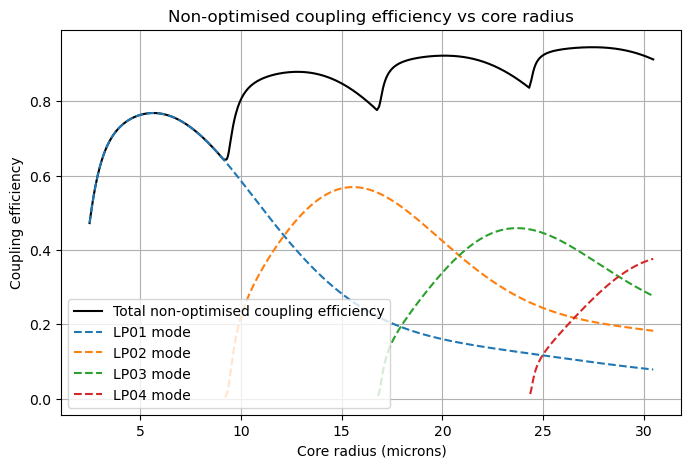

In [52]:
plt.figure(figsize=(8, 5))
plt.plot(core_radius_range_test * 1e6, eta_non_opt_all, label="Total non-optimised coupling efficiency", color="black")

plt.plot(core_radius_range_test * 1e6, eta_LP01, label="LP01 mode", linestyle="dashed")
plt.plot(core_radius_range_test * 1e6, eta_LP02, label="LP02 mode", linestyle="dashed")
plt.plot(core_radius_range_test * 1e6, eta_LP03, label="LP03 mode", linestyle="dashed")
plt.plot(core_radius_range_test * 1e6, eta_LP04, label="LP04 mode", linestyle="dashed")
# plt.plot(core_radius_range_test * 1e6, [mode["eta"] for mode in fibre_mode_non_opt_a_array], label="Non-optimised coupling efficiency of each mode", linestyle="dashed")
plt.xlabel("Core radius (microns)")
plt.ylabel("Coupling efficiency")
plt.title("Non-optimised coupling efficiency vs core radius")
plt.grid()
plt.legend()
plt.show()

In [54]:
def eta_background_from_psf_weights(decentre_array, eta_psf_array): 
    """
    Calculate the background coupling efficiency (eta_background) from the PSF coupling efficiency 
    (eta_psf(r)) as a function of decentre r. 

    The background coupling efficiency is calculated as the weighted average of the PSF coupling 
    efficiency over the image field, where the weights are given by the intensity distribution 
    of the image field (I_ext(r/f)). 

    eta_ext(background) = ∫ eta_psf(r) * I_ext(r/f) dA / ∫ I_ext(r/f) dA, where A is the area of the image field.

    For the background, the image field would not be optimised via focal ratio, and the image field 
    of a decentred psf here would use the optimal F of the centred case. 

    Parameters: 
    decentre_array: 1D array of decentre values (r) in meters
    eta_psf_array: 1D array of PSF coupling efficiency values corresponding to each decentre value in decentre_array


    """
    # numerator = ∫ eta_psf(r) * I_ext(r/f) dA, where A=pi * r^2, so dA = 2 * pi * r dr  
    # I_ext(r^arrow) = I_0 for a completely uniform field, where I_0 is a constant that cancels out in the ratio, so we can ignore it in the calculation. 
    I_0=1.0
    numerator = integrate.simpson(eta_psf_array * I_0 * 2 * np.pi * decentre_array, x=decentre_array)
    # denominator = ∫ I_ext(r/f) dA, where A=pi * r^2, so dA = 2 * pi * r dr
    denominator = integrate.simpson(I_0 * 2 * np.pi * decentre_array, x=decentre_array)

    eta_background = numerator / denominator

    return eta_background



In [55]:

def eta_psf_vs_decentre_position_2d(
        prepared_modes, 
        x, y, x_1d, y_1d, 
        lam0, F_eff, alpha, 
        decentre_array, 
        E_S = 1.0, 
        direction_angle = 0.0
):
    """
    Calculate the coupling efficiency of a point source  as a function to its decentre relative 
    to the fibre. 

    Parameters: 
    prepared_modes: the pre-computed fibre modes containing eigenfield information for ONE core radius

    decentre_array: array of image positions relative to the fibre centre

    direction_angle: the angle of offset direction in the x-y grid plane
    Assuming angle is zero for a circularly symmetric aperature
    """

    eta_psf = [] # prepare array of eta_psf for each decentre coordinate
    mode_results_all = [] # not required but returns the fields of eigenmodes

    for r in decentre_array: # r is distance to centre
        dx = r * np.cos(direction_angle) # cos(0)=1, we are varying in the x direction
        dy = r * np.sin(direction_angle) # sin(0)=0 

        eta_total, mode_results = total_eff_2d(
            prepared_modes, 
            x, y, x_1d, y_1d, 
            lam0=lam0, 
            F_eff=F_eff, 
            alpha=alpha, 
            decentre=(dx, dy),
            E_S=E_S
        )

        eta_psf.append(eta_total)
        mode_results_all.append(mode_results)

    eta_psf = np.array(eta_psf)

    return eta_psf, mode_results_all


In [56]:
def background_no_opt_efficiency_at_one_radius_2d(
        a,
        x, y, x_1d, y_1d, 
        NA, lam0, 
        alpha=0.0, 
        az_sym=True, 
        mode_case="smf", 
        decentre_max=None, 
        n_decentre=50, E_S=1.0, 
        n_F_grid=60, 
        # F_opt_input=None
        F_eff=F_fibre
):
    """
    For one fibre core radius a: 
        1. Prepare fibre modes
        2. Optimise F_eff for centred point source
        3. Calculate eta_psf(d)
        4. Integrate eta_psf(d) to get flat-background efficiency

    Parameters: 
    decentre_max: the maximum decentre radius, set to None, but equals to the cladding radius
    n_decentre: the number of decentre points to consider
    E_S: the electric field amplitude of the point source
    n_F_grid: the number of grid points for the F_eff calculation
    F_opt_input: 

    """

    V = 2 * np.pi * a * NA / lam0

    prepared_modes = prepare_modes_2d(
        x, y, 
        a=a, 
        NA=NA, 
        lam0=lam0,
        az_sym=az_sym, 
        mode_case=mode_case
    )

    eta_centre, mode_results_centred = total_eff_2d(
        prepared_modes,
        x=x, y=y, x_1d=x_1d, y_1d=y_1d,
        lam0=lam0,
        F_eff=F_fibre,
        alpha=alpha,
        decentre=None,
        E_S=E_S
    )

    E_image_opt, I_image_opt = diffraction_limited_E_field_at_fibre_2d(
        x, y,
        lam0=lam0,
        F_eff=F_fibre,
        alpha=alpha,
        E_S=E_S,
        decentre=None
    )

    # Choose decentre_max to be the cladding radius if not specified
    if decentre_max is None: 
        r_max = 125e-6 # in meters, this is the maximum radius of the grid we prepared for the field calculations, so we can't go beyond this
        decentre_max = r_max # cladding radius 

    decentre_array = np.linspace(0, decentre_max, n_decentre)

    # Calculate eta_psf(d) for the range of decentre values
    eta_psf,  mode_results_decentre = eta_psf_vs_decentre_position_2d(
        prepared_modes, 
        x, y, x_1d, y_1d,
        lam0=lam0, F_eff=F_fibre, alpha=alpha,
        decentre_array=decentre_array,
        E_S=E_S
    )

    # Integrate over the flat background, assume I_background is unitorm so I_ext(r/f) = I_0, 
    # where I_0 is a constant that cancels out in the ratio, so we can ignore it in the calculation.
    eta_background = eta_background_from_psf_weights(decentre_array, eta_psf)
    
    return {
        "a": a,
        "V": V,
        "F_eff": F_fibre,
        "eta_centre": eta_centre,
        "eta_background": eta_background,
        "decentre_array": decentre_array,
        "eta_psf": eta_psf,
        "mode_results_centred": mode_results_centred,
        "mode_results_decentre": mode_results_decentre,
        "E_image_opt": E_image_opt,
        "I_image_opt": I_image_opt
    }


In [57]:
def background_efficiency_vs_core_radius_2d(
        core_radius_array, 
        x, y, x_1d, y_1d,
        NA, lam0,
        alpha=0.0,
        az_sym=True,
        mode_case="smf",
        decentre_max=None,
        n_decentre=50, 
        E_S=1.0, 
        n_F_grid=60,
        n_jobs=1, 
        # F_opt_array = None
):
    """Loop over core radius and calculate: 
        - centred point source efficiency at optimal F
        - background efficiency by the weighted average of a number of decentred point source efficiencies

    Parameters:
    core_radius_array: array of core radius values to process
    x, y, x_1d, y_1d: grid points for the field calculations
    NA: numerical aperture
    lam0: wavelength
    alpha: polarization angle
    az_sym: whether to use azimuthal symmetry
    mode_case: case for mode calculation
    decentre_max: maximum decentre radius
    n_decentre: number of decentre points
    E_S: electric field amplitude of the point source
    n_F_grid: number of grid points for F_eff calculation
    n_jobs: number of parallel workers. Use 1 for serial, >1 for parallel.

    Return: 
    results: list of dictionaries containing the background efficiency and other related 
    information for each core radius in the range of core_radius_array
    """
    # Count how many individual core radiuses are computed
    n_total = len(core_radius_array)
    # if F_opt_array is not None and len(F_opt_array) == n_total:
    #     F_opt_array = np.asarray(F_opt_array)

    def run_one_radius(i, a):
        # if F_opt_array is None: 
        #     F_opt_input = None 
        # else: 
        #     F_opt_input = F_opt_array[i]

        row = background_no_opt_efficiency_at_one_radius_2d(
            a=a, 
            x=x, y=y, x_1d=x_1d, y_1d=y_1d,
            NA=NA, 
            lam0=lam0,
            alpha=alpha,
            az_sym=az_sym, 
            mode_case=mode_case,
            decentre_max=decentre_max, 
            n_decentre=n_decentre, 
            E_S=E_S,
            n_F_grid=n_F_grid, 
            F_eff=F_fibre # remember to pass the F_opt_input for each radius if provided
        )
        return row
    



    if n_jobs == 1:
        results = []

        checkpoints = {
            max(1, int(np.ceil(n_total * p / 10))) 
            for p in range(1, 11)
        }

        for i, a in enumerate(core_radius_array, start=0):
            results.append(run_one_radius(i,a))

            step=i + 1 # step is the number of core radiuses we have processed so far, starting from 1

            if i in checkpoints:
                percent = int(round(100 * step / n_total))
                print(f"{percent}% complete ({step}/{n_total})")

    else:
        results = Parallel(n_jobs=n_jobs, verbose=10)(
            delayed(run_one_radius)(i,a)
            for i, a in enumerate(core_radius_array, start=0)
        )

    return results

In [ ]:
# core_radius_test_small = np.linspace(1.2e-6, 20e-6, 80)
results_bg_mmf = background_efficiency_vs_core_radius_2d(
    core_radius_array=core_radius_range_test,
    x=x,
    y=y,
    x_1d=x_1d,
    y_1d=y_1d,
    NA=NA,
    lam0=lam0,
    alpha=0.0,
    az_sym=False,
    mode_case="few_mode",
    decentre_max=None,
    n_decentre=40,
    E_S=1.0,
    n_F_grid=60, 
    n_jobs=4, 
    # F_opt_array = F_opt_arr
)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
python(87924) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(87925) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(87926) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(87927) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    5.0s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    7.0s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:   10.8s
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:   12.7s
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:   18.6s
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   23.1s
[Parallel(n_jobs=4)]: Done  53 tasks      | elapsed:   31.0s
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:   37.4s
[Parallel(n_jobs=4)]: Done  77 tasks      | e

In [160]:
a_arr = np.array([row["a"] for row in results_bg_mmf])
eta_centre_arr = np.array([row["eta_centre"] for row in results_bg_mmf])
eta_bg_arr = np.array([row["eta_background"] for row in results_bg_mmf])

In [161]:
# idx = 500   # choose a larger core radius index

# a_test = results_bg_mmf[idx]["a"]
# mode_results = results_bg_mmf[idx]["mode_results_centred"]

# print(f"a = {a_test*1e6:.2f} µm")
# print("Number of mode branches:", len(mode_results))
# print("Modes:")

# for mode in mode_results:
#     print(mode["l"], mode["m"], mode.get("angular", None), f"eta={mode['eta']:.4f}")

In [162]:
from scipy.interpolate import interp1d
target_radii_um = [5, 12.5, 20, 27.5] # in microns
target_radii_m = np.array(target_radii_um) * 1e-6 # convert to meters

result_fixed_a_list = []
eta_2d_map_list = []

a_array = np.array([row["a"] for row in results_bg_mmf])

for target_a in target_radii_m:
    # Find the index of the closest core radius in the results
    idx = np.argmin(np.abs(a_array - target_a))
    result_fixed_a = results_bg_mmf[idx]

    # Extract the relevant data for this core radius
    a_at_target = result_fixed_a["a"]
    decentre_array = result_fixed_a["decentre_array"]
    eta_psf_array = result_fixed_a["eta_psf"]

    print(f"Target radius = {target_a*1e6:.1f} micron")
    print(f"Closest stored radius = {a_at_target*1e6:.3f} micron")

    # Build interpolation function eta_psf(d), which we will use to convert the radial eta_psf(d) 
    # into a 2D eta map
    eta_interp = interp1d(
        decentre_array,
        eta_psf_array,
        bounds_error=False,
        fill_value=0.0
    )

    # Make x-y decentre coordinate grid
    d_max = np.max(decentre_array)

    n_map = 300 # number of points in the x and y directions for the 2D map
    x_dec_1d = np.linspace(-d_max, d_max, n_map)
    y_dec_1d = np.linspace(-d_max, d_max, n_map)

    X_dec, Y_dec = np.meshgrid(x_dec_1d, y_dec_1d)

    # Radial decentre distance
    D_dec = np.sqrt(X_dec**2 + Y_dec**2)

    # Convert radial eta_psf(d) into 2D eta map
    eta_map_2d = eta_interp(D_dec)

    # Mask outside circular averaging region
    eta_map_2d = eta_interp(D_dec) # convert radial eta_psf(d) into 2D eta map, using D_dec the radial decentre distance
    eta_map_2d[D_dec > d_max] = np.nan # mask outside circular

    result_fixed_a_list.append(result_fixed_a)
    eta_2d_map_list.append(eta_map_2d)



Target radius = 5.0 micron
Closest stored radius = 5.000 micron
Target radius = 12.5 micron
Closest stored radius = 12.500 micron
Target radius = 20.0 micron
Closest stored radius = 20.000 micron
Target radius = 27.5 micron
Closest stored radius = 27.500 micron


In [163]:
a_5um = result_fixed_a_list[0]["a"]
decentre_array_5um = result_fixed_a_list[0]["decentre_array"]
eta_psf_5um = result_fixed_a_list[0]["eta_psf"]

a_12p5um = result_fixed_a_list[1]["a"]
decentre_array_12p5um = result_fixed_a_list[1]["decentre_array"]
eta_psf_12p5um = result_fixed_a_list[1]["eta_psf"]

a_20um = result_fixed_a_list[2]["a"]
decentre_array_20um = result_fixed_a_list[2]["decentre_array"]
eta_psf_20um = result_fixed_a_list[2]["eta_psf"]

a_27p5um = result_fixed_a_list[3]["a"]
decentre_array_27p5um = result_fixed_a_list[3]["decentre_array"]
eta_psf_27p5um = result_fixed_a_list[3]["eta_psf"]

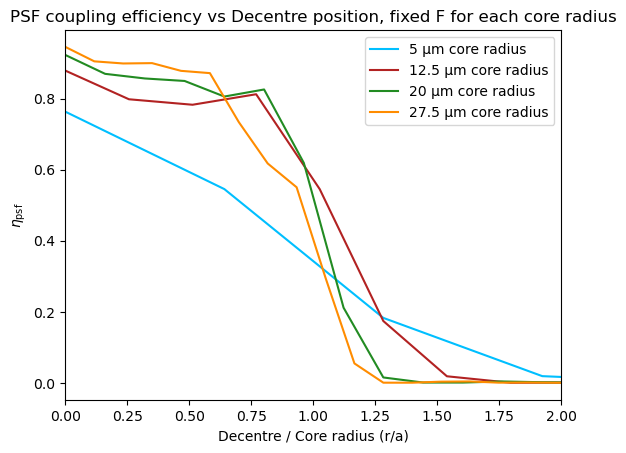

In [164]:
plt.plot(decentre_array / a_5um, eta_psf_5um, color='deepskyblue', label='5 µm core radius')
plt.plot(decentre_array / a_12p5um, eta_psf_12p5um, color='firebrick', label='12.5 µm core radius')
plt.plot(decentre_array / a_20um, eta_psf_20um, color='forestgreen', label='20 µm core radius')
plt.plot(decentre_array / a_27p5um, eta_psf_27p5um, color='darkorange', label='27.5 µm core radius')
plt.xlabel("Decentre / Core radius (r/a)")
plt.ylabel(r"$\eta_{\rm psf}$")
plt.title(f"PSF coupling efficiency vs Decentre position, fixed F for each core radius")
plt.xlim(0, 2)
plt.legend()
plt.show()

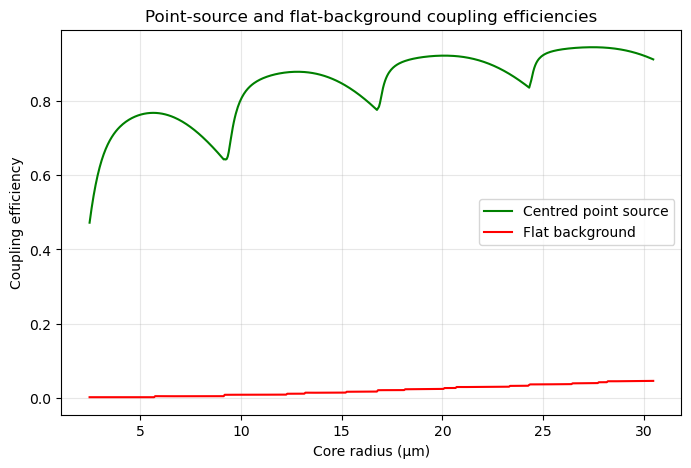

In [165]:
plt.figure(figsize=(8, 5))
plt.plot(a_arr * 1e6, eta_non_opt_all, label="Centred point source", color='green')
plt.plot(a_arr * 1e6, eta_bg_arr, label="Flat background", color='red')
plt.xlabel("Core radius (µm)")
plt.ylabel("Coupling efficiency")
plt.title("Point-source and flat-background coupling efficiencies")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

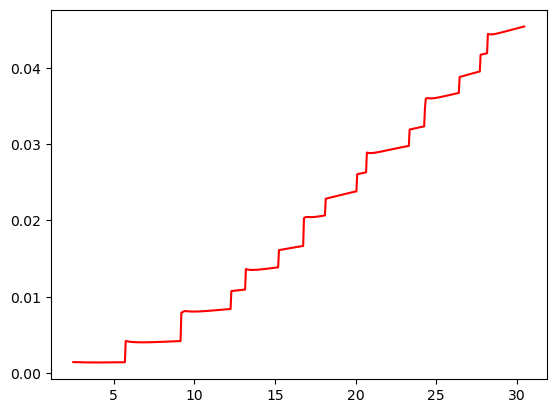

In [166]:
plt.plot(a_arr * 1e6, eta_bg_arr, label="Flat background", color='red')


In [168]:
NA

0.1

In [ ]:
# from scipy import integrate
# import numpy as np
# import matplotlib.pyplot as plt

Magnification = F_fibre / 49.9
F_focus = 49.9
D_M1 = 8.0
alpha = 0.0

I_flat = 1.0

rad_to_arcsec = (180 / np.pi) * 3600
plate_scale_coude = rad_to_arcsec / (F_focus * D_M1)  # arcsec / metre at telescope focal plane

# Extract arrays
core_radius_arr = np.array([row["a"] for row in results_bg_mmf])
# F_opt_arr = np.array([row["F_opt"] for row in results_bg_mmf])
eta_background_arr = np.array([row["eta_background"] for row in results_bg_mmf])

# This should come from the signal/centred optimisation result
eta_total_arr = eta_non_opt_all
# If your key is different, use:
# eta_total_arr = np.array([row["eta_centre"] for row in results_bg_mmf])

signal_incident_array = np.zeros_like(core_radius_arr)
signal_coupled_array = np.zeros_like(core_radius_arr)
FOV_array = np.zeros_like(core_radius_arr)
background_incident_array = np.zeros_like(core_radius_arr)
background_coupled_array = np.zeros_like(core_radius_arr)
snr_array = np.zeros_like(core_radius_arr)
Magnification_array = np.zeros_like(core_radius_arr)

for i, a in enumerate(core_radius_arr):

    # I_image = data_few_sym_2d[i]["I_image_opt"]  # should be 2D

    # F_opt = F_opt_arr[i]

    # Magnification = F_opt / F_focus
    # Magnification_array[i] = Magnification

    plate_scale_demag = plate_scale_coude / Magnification

    # Geometric fibre field of view in arcsec
    FOV = plate_scale_demag * 2 * a
    FOV_array[i] = FOV

    # 2D incident point-source image power
    # signal_x = integrate.simpson(I_image, x=x_1d, axis=1)
    # Signal_incident = integrate.simpson(signal_x, x=y_1d)

    # constant signal
    Signal0 = 1.0
    Signal_incident = Signal0

    # Coupled point-source signal
    Signal_coupled = Signal_incident * eta_total_arr[i]

    # Incident flat background over sky/FOV area
    Background_incident = I_flat * np.pi * (FOV / 2)**2

    # Coupled background
    Background_coupled = Background_incident * eta_background_arr[i]

    signal_incident_array[i] = Signal_incident
    signal_coupled_array[i] = Signal_coupled
    background_incident_array[i] = Background_incident
    background_coupled_array[i] = Background_coupled

    snr_array[i] = Signal_coupled / np.sqrt(Background_coupled)
    # snr_array[i] = eta_total_arr[i] / np.sqrt(eta_background_arr[i] * background_incident_array[i])

In [149]:
core_area_array = np.zeros_like(core_radius_arr)
for i, a in enumerate(core_radius_arr): 
    core_area = np.pi * core_radius_arr[i]**2
    core_area_array[i] = core_area

In [148]:
Magnification

np.float64(0.09969813999064328)

In [70]:
theta_psf = (lam0/D_M1) * (180/np.pi) * 3600  # convert from radians to arcseconds
theta_psf

0.03867465117133057

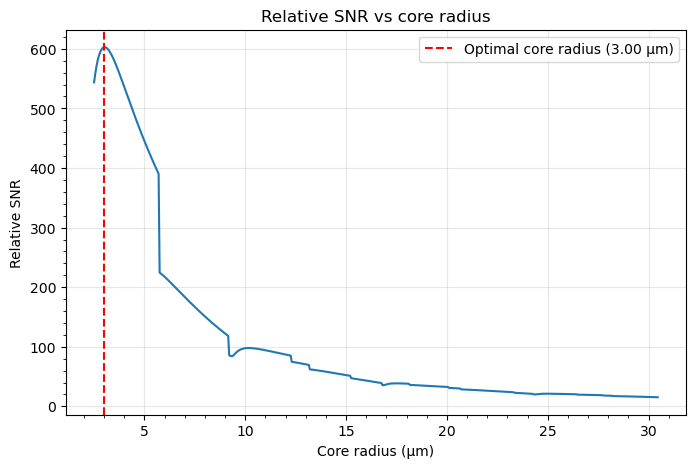

In [78]:
snr_rel = snr_array 


plt.figure(figsize=(8, 5))
plt.plot(core_radius_arr * 1e6, snr_rel)
plt.axvline(core_radius_arr[np.argmax(snr_rel)] * 1e6, color='red', linestyle='dashed', label=f"Optimal core radius ({core_radius_arr[np.argmax(snr_rel)] * 1e6:.2f} µm)")
plt.xlabel("Core radius (µm)")
plt.ylabel("Relative SNR")
plt.title("Relative SNR vs core radius")
# add minor ticks
plt.gca().minorticks_on()
plt.grid(True, alpha=0.3)
plt.legend()

Text(0.5, 1.0, 'Coupling Efficiency of LP01 Mode vs Core Radius')

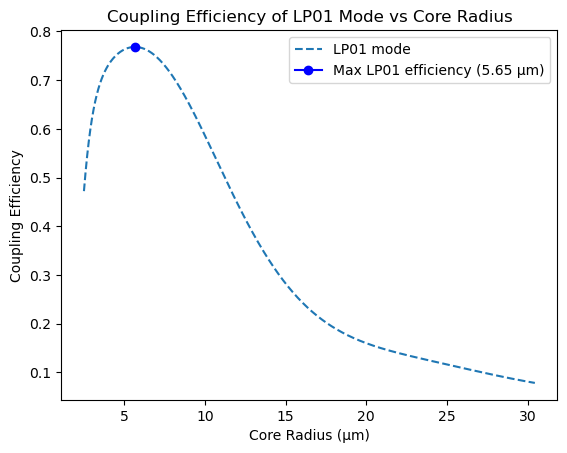

In [146]:
plt.plot(core_radius_range_test * 1e6, eta_LP01, label="LP01 mode", linestyle="dashed")
plt.plot(core_radius_range_test[np.argmax(eta_LP01)] * 1e6, np.max(eta_LP01), label=f"Max LP01 efficiency ({core_radius_range_test[np.argmax(eta_LP01)] * 1e6:.2f} µm)", marker='o', color='blue')
plt.xlabel("Core Radius (μm)")
plt.ylabel("Coupling Efficiency")
plt.legend()
plt.title("Coupling Efficiency of LP01 Mode vs Core Radius")

Text(0.5, 1.0, 'Coupling Efficiency of LP01 Mode vs Core Radius')

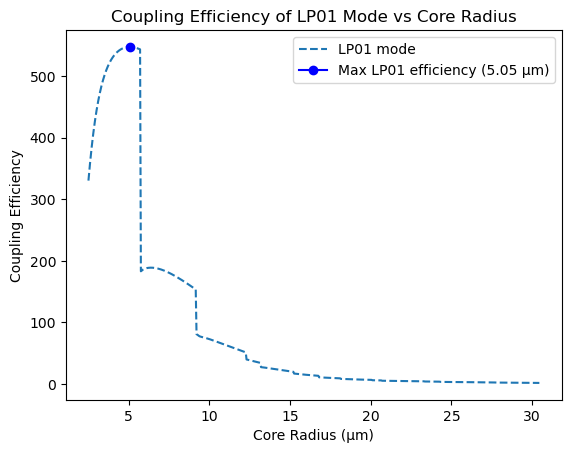

In [153]:
plt.plot(core_radius_range_test * 1e6, eta_LP01 / eta_bg_arr, label="LP01 mode", linestyle="dashed")
plt.plot(core_radius_range_test[np.argmax(eta_LP01 / eta_bg_arr)] * 1e6, np.max(eta_LP01 / eta_bg_arr), label=f"Max LP01 efficiency ({core_radius_range_test[np.argmax(eta_LP01 / eta_bg_arr)] * 1e6:.2f} µm)", marker='o', color='blue')
plt.xlabel("Core Radius (μm)")
plt.ylabel("Coupling Efficiency")
plt.legend()
plt.title("Coupling Efficiency of LP01 Mode vs Core Radius")

Text(0.5, 1.0, 'Coupling Efficiency of LP01 Mode vs Core Radius')

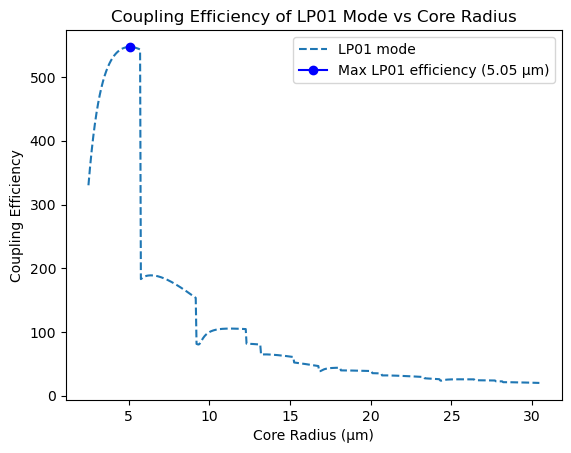

In [154]:
plt.plot(core_radius_range_test * 1e6, eta_total_arr / eta_bg_arr, label="LP01 mode", linestyle="dashed")
plt.plot(core_radius_range_test[np.argmax(eta_total_arr / eta_bg_arr)] * 1e6, np.max(eta_total_arr / eta_bg_arr), label=f"Max LP01 efficiency ({core_radius_range_test[np.argmax(eta_total_arr / eta_bg_arr)] * 1e6:.2f} µm)", marker='o', color='blue')
plt.xlabel("Core Radius (μm)")
plt.ylabel("Coupling Efficiency")
plt.legend()
plt.title("Coupling Efficiency of LP01 Mode vs Core Radius")

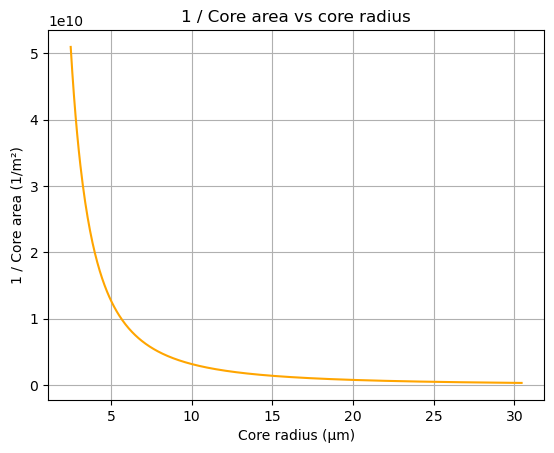

In [151]:
plt.plot(core_radius_arr * 1e6, 1 / core_area_array, label="Core area", color='orange')
plt.xlabel("Core radius (µm)")
plt.ylabel("1 / Core area (1/m²)")
plt.title("1 / Core area vs core radius")
plt.grid()

Core radius with FOV closest to PSF size: 3.75 µm, FOV: 0.04 arcsec, PSF size (theta_psf): 0.04 arcsec


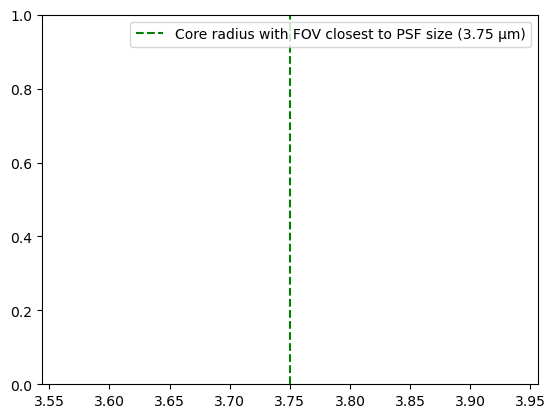

In [143]:
# Find the radius where the FOV is closest to the PSF size
idx_closest_psf = np.argmin(np.abs(FOV_array - theta_psf))
print(f"Core radius with FOV closest to PSF size: {core_radius_arr[idx_closest_psf] * 1e6:.2f} µm, FOV: {FOV_array[idx_closest_psf]:.2f} arcsec, PSF size (theta_psf): {theta_psf:.2f} arcsec")
plt.axvline(core_radius_arr[idx_closest_psf] * 1e6, color='green', linestyle='dashed', label=f"Core radius with FOV closest to PSF size ({core_radius_arr[idx_closest_psf] * 1e6:.2f} µm)")
plt.legend()
plt.show()

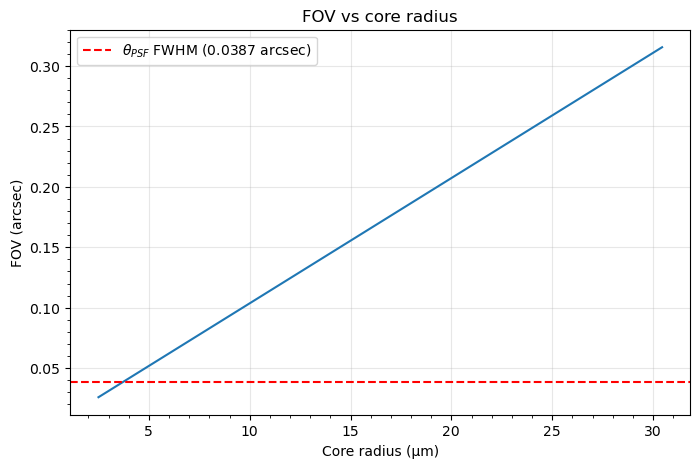

In [133]:
plt.figure(figsize=(8, 5))
plt.plot(core_radius_arr * 1e6, FOV_array)
plt.axhline(theta_psf, color='red', linestyle='dashed', label=f"$\\theta_{{PSF}}$ FWHM ({theta_psf:.4f} arcsec)")

plt.xlabel("Core radius (µm)")
plt.ylabel("FOV (arcsec)")
plt.title("FOV vs core radius")
plt.legend()
# add minor ticks
plt.gca().minorticks_on()
plt.grid(True, alpha=0.3)
plt.show()

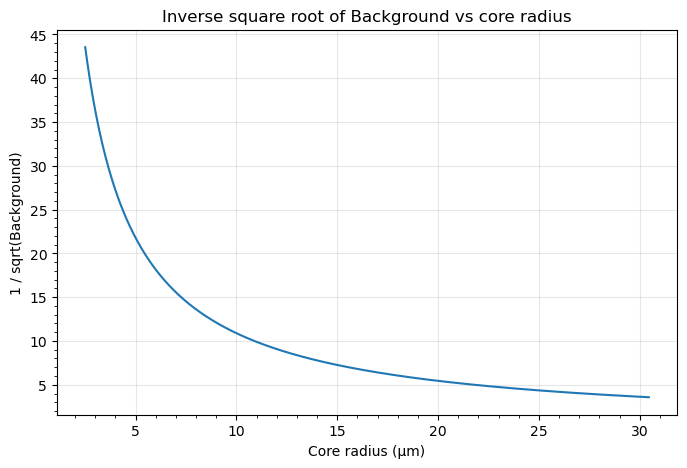

In [139]:
plt.figure(figsize=(8, 5))
plt.plot(core_radius_arr * 1e6, 1 / np.sqrt(background_incident_array))
# plt.axhline(theta_psf, color='red', linestyle='dashed', label=f"PSF FWHM ({theta_psf:.2f} arcsec)")

plt.xlabel("Core radius (µm)")
plt.ylabel("1 / sqrt(Background)")
plt.title("Inverse square root of Background vs core radius")
# add minor ticks
plt.gca().minorticks_on()
plt.grid(True, alpha=0.3)
plt.show()

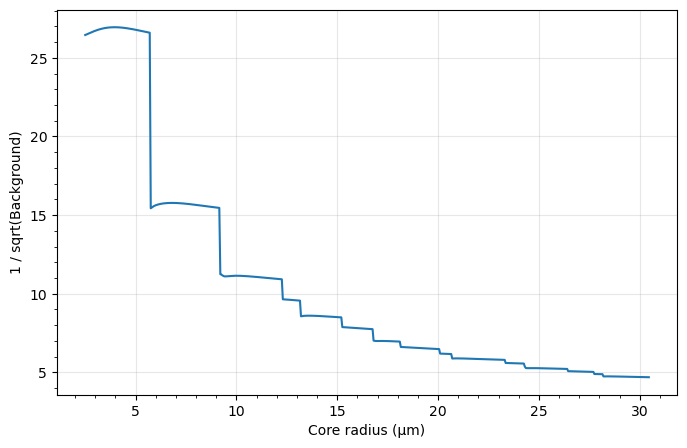

In [82]:
plt.figure(figsize=(8, 5))
plt.plot(core_radius_arr * 1e6, 1 / np.sqrt(eta_bg_arr))
# plt.axhline(theta_psf, color='red', linestyle='dashed', label=f"PSF FWHM ({theta_psf:.2f} arcsec)")

plt.xlabel("Core radius (µm)")
plt.ylabel("1 / sqrt(Background)")
# add minor ticks
plt.gca().minorticks_on()
plt.grid(True, alpha=0.3)
plt.show()

<>:9: SyntaxWarning: invalid escape sequence '\e'
<>:9: SyntaxWarning: invalid escape sequence '\e'
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_83228/832331107.py:9: SyntaxWarning: invalid escape sequence '\e'
  plt.title("Relative SNR vs core radius (without $\eta_{background}$)")


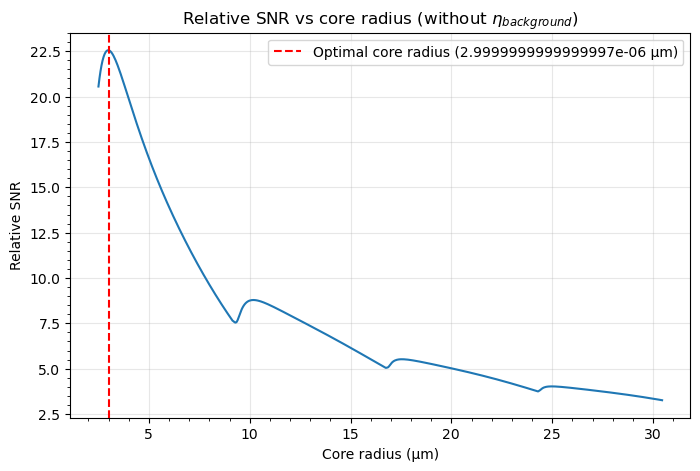

In [147]:
snr_rel = snr_array 


plt.figure(figsize=(8, 5))
plt.plot(core_radius_arr * 1e6, signal_coupled_array / np.sqrt(background_incident_array))
plt.axvline(core_radius_arr[np.argmax(signal_coupled_array / np.sqrt(background_incident_array))] * 1e6, color='red', linestyle='dashed', label=f"Optimal core radius ({core_radius_arr[np.argmax(signal_coupled_array / np.sqrt(background_incident_array))]} µm)")
plt.xlabel("Core radius (µm)")
plt.ylabel("Relative SNR")
plt.title("Relative SNR vs core radius (without $\eta_{background}$)")
# add minor ticks
plt.gca().minorticks_on()
plt.grid(True, alpha=0.3)
plt.legend()

In [101]:
E_image, I_image = diffraction_limited_E_field_at_fibre_2d(
    x, y,
    lam0=lam0,
    F_eff=F_fibre,
    alpha=alpha,
    E_S=E_S,
    decentre=None
)

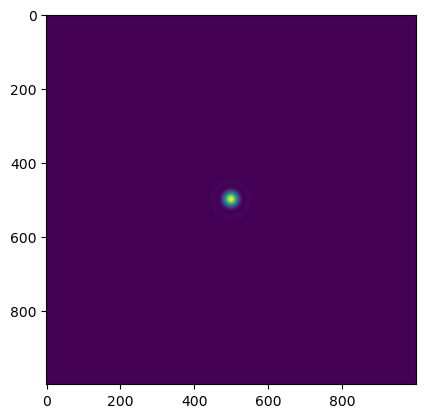

In [108]:
plt.imshow(I_image)

In [ ]:
# Set fibre core radius as aperature size, and calculate the eircled energy of the PSF within this radius, to compare with the coupled efficiency of the point source.

core_radius_arr = np.array([row["a"] for row in results_bg_mmf])

EE_arr = np.zeros_like(core_radius_arr)
snr_aperature_arr = np.zeros_like(core_radius_arr)
Background_aperature_arr = np.zeros_like(core_radius_arr)

R_grid = np.sqrt(x**2 + y**2)

I_flat = 1.0

for i, a in enumerate(core_radius_arr):

    I_image = I_image
    
    P_total_x = integrate.simpson(I_image, x=x_1d, axis=1)
    P_total = integrate.simpson(P_total_x, x=y_1d)

    aperature_mask = R_grid <= a
    I_inside = np.where(aperature_mask, I_image, 0) # replace value inside the aperature with the original intensity, and outside with zero

    P_inside_x = integrate.simpson(I_inside, x=x_1d, axis=1)
    P_inside = integrate.simpson(P_inside_x, x=y_1d)

    EE = P_inside / P_total
    EE_arr[i] = EE

    Background = np.pi * (FOV_array[i] / 2)**2
    
    Background_aperature_arr[i] = Background
    snr_aperature_arr[i] = EE / np.sqrt(Background * eta_bg_arr[i]) 



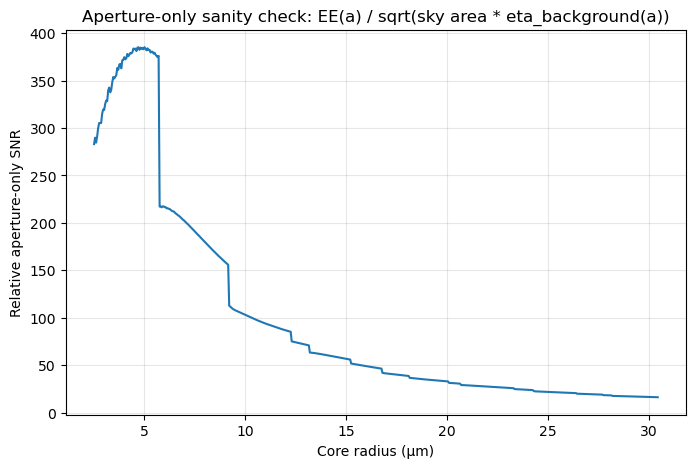

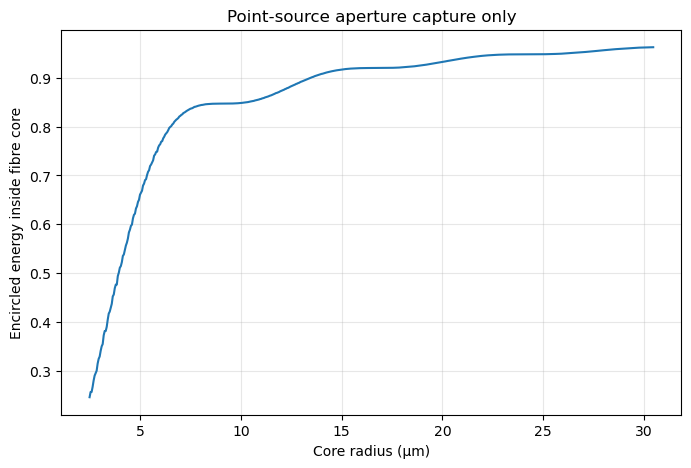

In [113]:

plt.figure(figsize=(8, 5))
plt.plot(core_radius_arr * 1e6, snr_aperature_arr)
plt.xlabel("Core radius (µm)")
plt.ylabel("Relative aperture-only SNR")
plt.title("Aperture-only sanity check: EE(a) / sqrt(sky area * eta_background(a))")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(core_radius_arr * 1e6, EE_arr)
plt.xlabel("Core radius (µm)")
plt.ylabel("Encircled energy inside fibre core")
plt.title("Point-source aperture capture only")
plt.grid(True, alpha=0.3)
plt.show()

In [119]:
core_radius_arr[np.argmax(EE_arr / np.sqrt(Background_aperature_arr))]

np.float64(4.999999999999998e-06)

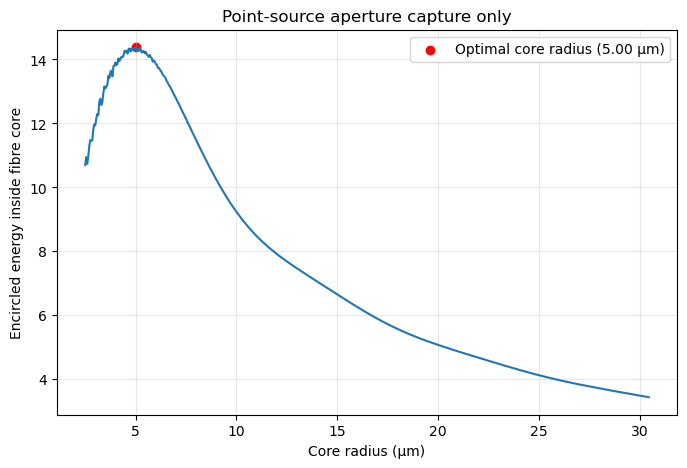

In [121]:
plt.figure(figsize=(8, 5))
plt.plot(core_radius_arr * 1e6, EE_arr / np.sqrt(Background_aperature_arr))
plt.scatter(core_radius_arr[np.argmax(EE_arr / np.sqrt(Background_aperature_arr))] * 1e6, (EE_arr / np.sqrt(Background_aperature_arr))[np.argmax(EE_arr / np.sqrt(Background_aperature_arr))], 
            color='red', label=f"Optimal core radius ({core_radius_arr[np.argmax(EE_arr / np.sqrt(Background_aperature_arr))] * 1e6:.2f} µm)")
plt.xlabel("Core radius (µm)")
plt.ylabel("Encircled energy inside fibre core")
plt.title("Point-source aperture capture only")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Text(0.5, 1.0, 'Background area vs core radius')

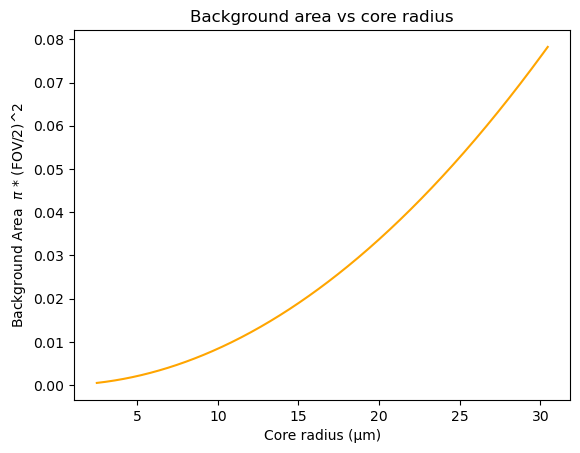

In [136]:
plt.plot(core_radius_arr * 1e6, Background_aperature_arr, label="Background in fibre aperature", color='orange')
plt.xlabel("Core radius (µm)")
plt.ylabel("Background Area  $\\pi$ * (FOV/2)^2")
plt.title("Background area vs core radius")